## 1. Import Libraries

In [72]:
import pandas as pd
from sklearn import datasets
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import statsmodels.api as stm
import seaborn as sns

## 2. Data Collection

In [4]:
diabetes_ds = datasets.load_diabetes()

In [8]:
diabtes_df = pd.DataFrame(diabetes_ds.data,columns=diabetes_ds.feature_names
            )

In [9]:
print(diabetes_ds.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [12]:
diabtes_df["Target"] = pd.DataFrame(diabetes_ds.target)

In [13]:
diabtes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 3. Data Understanding

In [14]:
diabtes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [17]:
diabtes_df.isna().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64

In [18]:
diabtes_df.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
Target    float64
dtype: object

### 3.1 Validate the Assumption

#### Linearity Test

In [64]:
diabtes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


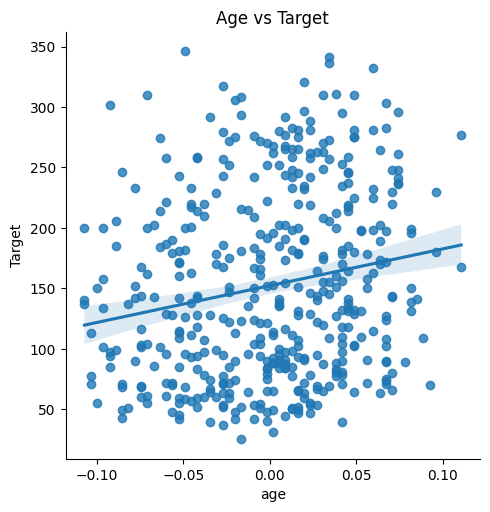

In [68]:
sns.lmplot(diabtes_df,x="age",y="Target",)
plt.title("Age vs Target")
plt.show()

#### 3.2 Normality Test

<Axes: xlabel='age', ylabel='Count'>

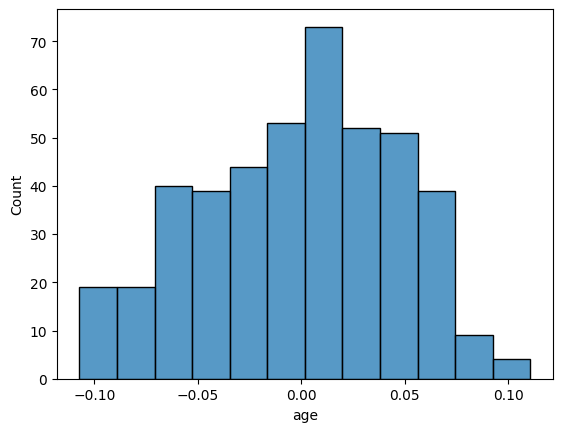

In [69]:
sns.histplot(data=diabtes_df,x="age")

## 4. Data Preparation

In [20]:
X = diabtes_df.drop("Target",axis=1)

In [21]:
y = diabtes_df["Target"]

In [22]:
X.shape,y.shape

((442, 10), (442,))

In [30]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: Target, dtype: float64

## 5. Module Selection/Building

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=12,shuffle=True)

In [33]:
ln_Module = LinearRegression()

## 6. Module Training

In [34]:
ln_Module.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 7. Module Testing

### 7.1 Train Data

In [38]:
y_predict_train = ln_Module.predict(X_train)

### 7.2 Test Data

In [37]:
y_predict_test = ln_Module.predict(X_test)

## 8. Module Evaluation

### 8.1 Train Data

In [43]:
tr_mae = mean_absolute_error(y_train,y_predict_train)

In [45]:
tr_mse = mean_squared_error(y_train,y_predict_train)

In [47]:
np.sqrt(tr_mse)

np.float64(53.014258469861694)

In [49]:
tr_r2score = r2_score(y_train,y_predict_train)

In [50]:
print("Train Mean_abs_Err : ", tr_mae)
print("Train Mean_sqr_Err : ", tr_mse)
print("Train R2_score : ", tr_r2score)

Train Mean_abs_Err :  42.77724385539974
Train Mean_sqr_Err :  2810.5116011093023
Train R2_score :  0.5424677165685909


### 8.2 Test Data

In [52]:
ts_mae = mean_absolute_error(y_test,y_predict_test)

In [53]:
ts_mse = mean_squared_error(y_test,y_predict_test)

In [57]:
np.sqrt(ts_mse)

np.float64(55.751278769977965)

In [58]:
ts_r2score = r2_score(y_test,y_predict_test)

In [59]:
print("Train Mean_abs_Err : ", ts_mae)
print("Train Mean_sqr_Err : ", ts_mse)
print("Train R2_score : ", ts_r2score)

Train Mean_abs_Err :  45.83439813168889
Train Mean_sqr_Err :  3108.2050844877954
Train R2_score :  0.3852693902152976


In [61]:
X.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


<Axes: >

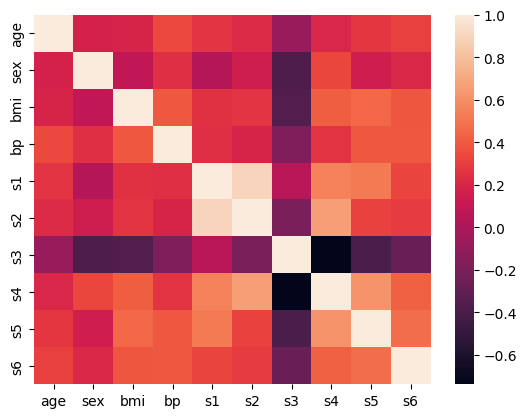

In [63]:
sns.heatmap(X.corr())

## Zero Residual

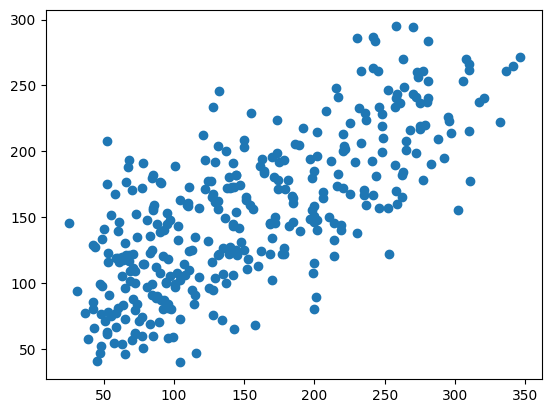

In [70]:
plt.scatter(x = y_train,y=y_predict_train)

In [78]:
stm_module = stm.OLS(y_train,X_train).fit()

In [80]:
stm_module.rsquared,stm_module.rsquared_adj

(np.float64(0.11892021236345118), np.float64(0.09323275499795403))